# Limpieza, unificación y EDA de recetas

## Contexto

**ChefWise** es un recomendador de comidas. El frontend (Angular) espera el contrato
de `frontend/src/app/models/recipe.model.ts`: nombre, categoría, minutos, porciones,
dificultad, ingredientes y pasos.

Este notebook deja las recetas listas para esa app: unificar fuentes, explorar si el
catálogo cubre lo que el recomendador necesita, y corregir lo que el EDA marque como
ruido o sesgo.

## Fuentes

1. **RecetasDeLaAbuela** — [somosnlp/RecetasDeLaAbuela](https://huggingface.co/datasets/somosnlp/RecetasDeLaAbuela).
2. **Kiwilimon** — scraping de [kiwilimon.com](https://www.kiwilimon.com/).

## Pipeline

`raw` → diagnóstico → limpieza inicial → unificación → **EDA orientado al recomendador** →
ajustes de limpieza → `processed`


In [17]:
import ast
import csv
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 140)


Matplotlib is building the font cache; this may take a moment.


## 1. Rutas

El notebook funciona tanto si el kernel arranca en `chefWise/` como en `notebooks/`.


In [18]:
cwd = Path.cwd().resolve()
if (cwd / "data" / "raw").is_dir():
    PROJECT_DIR = cwd
elif (cwd.parent / "data" / "raw").is_dir():
    PROJECT_DIR = cwd.parent
else:
    raise FileNotFoundError(
        "No se encontró data/raw. Abre el notebook desde chefWise/ o notebooks/."
    )

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
ABUELA_PATH = RAW_DIR / "recetasdelaabuela.csv"
KIWI_PATH = RAW_DIR / "recetas_kiwilimon.csv"
OUTPUT_PATH = PROCESSED_DIR / "recetas_unificadas_limpias.csv"

print("Proyecto:", PROJECT_DIR)
print("RecetasDeLaAbuela:", ABUELA_PATH, "| existe:", ABUELA_PATH.exists())
print("Kiwilimon:", KIWI_PATH, "| existe:", KIWI_PATH.exists())
print("Salida:", OUTPUT_PATH)

FIGURES_DIR = PROJECT_DIR / "notebooks" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Figuras:", FIGURES_DIR)


Proyecto: /Users/i./Documents/DIPLOMADO/MODULO_5/chefWise
RecetasDeLaAbuela: /Users/i./Documents/DIPLOMADO/MODULO_5/chefWise/data/raw/recetasdelaabuela.csv | existe: True
Kiwilimon: /Users/i./Documents/DIPLOMADO/MODULO_5/chefWise/data/raw/recetas_kiwilimon.csv | existe: True
Salida: /Users/i./Documents/DIPLOMADO/MODULO_5/chefWise/data/processed/recetas_unificadas_limpias.csv
Figuras: /Users/i./Documents/DIPLOMADO/MODULO_5/chefWise/notebooks/figures


## 2. Diagnóstico: RecetasDeLaAbuela

Revisamos forma, nulos, columnas basura y campos que no significan lo mismo en todas las filas.


In [19]:
abuela_raw = pd.read_csv(ABUELA_PATH)

print("Shape:", abuela_raw.shape)
print("Columnas:", abuela_raw.columns.tolist())
print("Duplicados exactos:", int(abuela_raw.duplicated().sum()))
print("Id único:", abuela_raw["Id"].is_unique)

nulos = abuela_raw.isna().mean().mul(100).round(1).sort_values(ascending=False)
display(nulos.to_frame("% nulos"))
display(abuela_raw.head(2))


Shape: (20085, 19)
Columnas: ['Id', 'Nombre', 'URL', 'Ingredientes', 'Pasos', 'Pais', 'Duracion', 'Porciones', 'Calorias', 'Categoria', 'Contexto', 'Valoracion y Votos', 'Comensales', 'Tiempo', 'Dificultad', 'Categoria 2', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18']
Duplicados exactos: 0
Id único: True


,% nulos
Unnamed: 17,100.0
Unnamed: 16,100.0
Calorias,100.0
Categoria 2,55.2
Tiempo,47.4
Contexto,41.6
Comensales,37.4
Categoria,34.6
Duracion,34.0
Valoracion y Votos,33.2


,Id,Nombre,URL,Ingredientes,Pasos,Pais,Duracion,Porciones,Calorias,Categoria,Contexto,Valoracion y Votos,Comensales,Tiempo,Dificultad,Categoria 2,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,1,Berenjenas rellenas,https://www.elmueble.com/cocinas/comidas-saludables_46627,"2 berenjenas, 1 pimiento rojo, 1 pimiento amarillo, 1 pimiento verde, 1 calabacín, 1 cebolleta, 100 ml de salsa de tomate, 4 huevos, 50 ...",Paso 1. Lava bien las berenjenas y pártelas por la mitad a lo largo. Vacíalas y cuécelas 5 minutos al vapor. Ponlas boca abajo para que ...,España,45 min,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Alto en fibra, Sin grasas trans, Sin sodio o sin sal",NaN,NaN,NaN
1,2,Alcachofas al horno con pico de gallo,https://www.elmueble.com/cocinas/comidas-saludables_46627,"4 alcachofas, 1 limón, 400 g de carne picada (mitad ternera, mitad cerdo), 1 cebolla blanca, 1 cebolla morada, 100 g de tomate frito, 2 ...","Paso 1. Precalentar el horno a 180?°C. , Paso 2. Pelar los tallos de las alcachofas, sin cortarlos; retirar las hojas exteriores y regar...",España,60 min,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Bajo en calorías, Sin grasa, Alto en fibra",NaN,NaN,NaN


### Hallazgos de esta fuente

- Hay tres columnas `Unnamed`. `Unnamed: 16` y `Unnamed: 17` están vacías.
  `Unnamed: 18` es un slug/título duplicado (exportación de RecetasGratis); no aporta señal nueva.
- `Calorias` está 100 % vacía → se descarta.
- `Porciones` **no es porciones** en la mayoría de filas: ~18k registros traen ahí
  una lista Python de ingredientes. Las porciones reales están en `Comensales`
  (`"4 comensales"`). Solo ~600 filas tienen un número en `Porciones`.
- `Tiempo` no es duración: es tipo de plato (`Plato principal`, `Desayuno`, `Entrante`…).
  La duración está en `Duracion`.
- `Ingredientes` y `Pasos` suelen ser listas serializadas (`['...']`); otras filas son
  texto separado por comas y etiquetas `Paso 1.`.
- Hay mojibake (`limÃ³n`) en algunos textos.
- `URL` cubre varios dominios; conviene conservar `source` por dominio.


In [20]:
print("Calorias no nulas:", int(abuela_raw["Calorias"].notna().sum()))
print("Unnamed:16/17 no nulas:", int(abuela_raw["Unnamed: 16"].notna().sum()), int(abuela_raw["Unnamed: 17"].notna().sum()))
print("Unnamed:18 no nulas:", int(abuela_raw["Unnamed: 18"].notna().sum()))

porciones = abuela_raw["Porciones"].dropna().astype(str)
print("\nPorciones que parecen lista:", int(porciones.str.startswith("[").sum()))
print("Porciones que parecen número:", int(porciones.str.fullmatch(r"\d+(?:\.\d+)?").sum()))

print("\nDominios:")
display(
    abuela_raw["URL"].astype(str).str.extract(r"https?://(?:www\.)?([^/]+)", expand=False)
    .value_counts(dropna=False)
    .head(10)
    .to_frame("recetas")
)
print("País:")
display(abuela_raw["Pais"].value_counts(dropna=False).head(12).to_frame("recetas"))
print("Dificultad:")
display(abuela_raw["Dificultad"].value_counts(dropna=False).to_frame("recetas"))
print("Tiempo (tipo de plato, no minutos):")
display(abuela_raw["Tiempo"].value_counts(dropna=False).head(12).to_frame("recetas"))
print("Ingredientes vacíos:", int(abuela_raw["Ingredientes"].isna().sum()))


Calorias no nulas: 0
Unnamed:16/17 no nulas: 0 0
Unnamed:18 no nulas: 18396

Porciones que parecen lista: 18187
Porciones que parecen número: 632

Dominios:


,recetas
URL,
recetasgratis.net,18396
yanuq.com,832
cookpad.com,720
directoalpaladar.com,92
elmueble.com,37
vitonica.com,8


País:


,recetas
Pais,
España,9486
Internacional,4436
Mexico,1922
Peru,1279
Perú,720
Argentina,632
NaN,496
Chile,251
Colombia,245


Dificultad:


,recetas
Dificultad,
Dificultad baja,10056
NaN,6303
Dificultad media,3010
Dificultad muy baja,399
Dificultad alta,305
Dificultad muy alta,12


Tiempo (tipo de plato, no minutos):


,recetas
Tiempo,
NaN,9527
Plato principal,3876
Entrante,2641
Postre,2061
Acompañamiento,674
Desayuno,530
Merienda,420
Cena,305
Cumpleaños,51


Ingredientes vacíos: 209


## 3. Diagnóstico: Kiwilimon

`pd.read_csv` falla: una fila del scrape pegó **dos recetas** (9 campos esperados, 17 encontrados).
Leemos con `csv.reader`, separamos esa fila y quitamos una cabecera repetida si aparece.


In [21]:
KIWI_COLUMNS = [
    "titulo", "dificultad", "tiempo", "tiempo_coccion",
    "ingredientes", "preparacion", "valoracion", "num_comentarios", "url",
]


def read_kiwilimon_with_repair(path: Path) -> tuple[pd.DataFrame, list]:
    rows = []
    malformed = []
    fused_pattern = re.compile(
        r"^(https?://www\.kiwilimon\.com/\S*?)"
        r"([A-ZÁÉÍÓÚÜÑ][^,]*?)\s*$"
    )

    expected_header = [c.lower() for c in KIWI_COLUMNS]
    with path.open(encoding="utf-8-sig", newline="", errors="replace") as f:
        for line_number, row in enumerate(csv.reader(f), start=1):
            if [c.strip().lower() for c in row] == expected_header:
                continue
            if len(row) == 9:
                rows.append(row)
                continue
            if len(row) == 17:
                malformed.append(line_number)
                fused = row[8]
                match = fused_pattern.match(fused)
                if not match:
                    raise ValueError(f"No se pudo reparar la fila {line_number}: {fused!r}")
                first_url, second_title = match.groups()
                first_row = row[:8] + [first_url]
                second_row = [second_title] + row[9:]
                if len(first_row) != 9 or len(second_row) != 9:
                    raise ValueError(f"Reparación inválida en fila {line_number}.")
                rows.extend([first_row, second_row])
                continue
            raise ValueError(f"Fila {line_number}: {len(row)} campos (se esperaban 9).")

    return pd.DataFrame(rows, columns=KIWI_COLUMNS), malformed


kiwi_raw, kiwi_repairs = read_kiwilimon_with_repair(KIWI_PATH)
header_like = kiwi_raw["titulo"].astype(str).str.strip().str.lower().eq("titulo")
kiwi_raw = kiwi_raw.loc[~header_like].reset_index(drop=True)

print("Shape tras reparación:", kiwi_raw.shape)
print("Líneas estructurales reparadas:", kiwi_repairs)
print("Cabeceras extra residuales eliminadas:", int(header_like.sum()))
print("Duplicados exactos:", int(kiwi_raw.duplicated().sum()))
print("Nulos por columna:")
display(kiwi_raw.replace("", np.nan).isna().sum().to_frame("nulos"))
display(kiwi_raw.head(3))
print("Dificultad:")
display(kiwi_raw["dificultad"].value_counts(dropna=False).to_frame("recetas"))


Shape tras reparación: (9020, 9)
Líneas estructurales reparadas: [2255]
Cabeceras extra residuales eliminadas: 0
Duplicados exactos: 0
Nulos por columna:


,nulos
titulo,0
dificultad,0
tiempo,0
tiempo_coccion,0
ingredientes,0
preparacion,2
valoracion,0
num_comentarios,0
url,0


,titulo,dificultad,tiempo,tiempo_coccion,ingredientes,preparacion,valoracion,num_comentarios,url
0,Brownies Pistache Nobles,Baja,20 mins,30 mins,"3/4 taza de harina, de avena, debe ser certificada libre de gluten (90 g) | 1/2 taza de cocoa, (42 g) | 3 cucharadas de fécula, de tapi...",Precalienta el horno a 170° C. | Engrasa el molde cuadrado de 24 cm y forra la base con papel. | En un tazón: cierne y mezcla los ingred...,5,1,https://www.kiwilimon.com/receta/postres/chocolate/brownies/brownies-pistache-nobles
1,Hojaldre con Queso de Cabra y Pinones,Baja,30 mins,0 mins,"150 gramos de masa de hojaldre, descongelada | 150 gramos de queso de cabra blanco | 1 taza de mermelada de chabacano | 1 cebolla, blanc...","En una olla derrita la mantequilla a fuego medio, agregue las cebollas y sazone con sal y pimienta. Cocine hasta que comienze a hervir l...",5,1,https://www.kiwilimon.com/receta/recetas-de-botanas-faciles/hojaldre-con-queso-de-cabra-y-pinones
2,Egg Cake con Espárragos,Baja,25 mins,20 mins,cantidad suficiente de aceite en aerosol | 12 claras de huevo | 1/2 taza de cebolla | 1/2 taza de pimiento morrón | 1/2 taza de espárra...,"Precalienta el horno a 175°C. | Rocía con un poco de aceite en aerosol el molde para cupcakes. | Agrega a una batidora las claras, la ce...",5,1,https://www.kiwilimon.com/receta/desayunos/egg-cake-con-esparragos


Dificultad:


,recetas
dificultad,
Baja,7637
Media,1271
Alta,112


## 4. Funciones de limpieza

Reglas:

- No reescribir recetas ni “corregir” ingredientes.
- Homogeneizar listas (`[...]` o `|`) a texto separado por ` | `.
- Reparar mojibake UTF-8 leído como Latin-1 cuando se pueda.
- Parsear tiempos a minutos y valoraciones a número.
- Mapear dificultad y tipo de comida al contrato de la app cuando sea razonable;
  si no hay evidencia, dejar nulo.


In [22]:
_MOJI_FIXED = (
    ("Ã¡", "á"), ("Ã©", "é"), ("Ãí", "í"), ("Ãó", "ó"), ("Ãú", "ú"),
    ("Ãñ", "ñ"), ("Ãü", "ü"), ("ÃÁ", "Á"), ("ÃÍ", "Í"),
    ("ÃÓ", "Ó"), ("ÃÚ", "Ú"), ("ÃÑ", "Ñ"), ("Ã ", "à"),
    ("Ã‰", "É"),  # Ã‰  (cp1252)
    ("Ãš", "Ú"),  # Ãš
)



def _repair_mojibake_pairs(text: str) -> str:
    """Corrige pares tipo Ã© mezclados con texto ya bien decodificado."""
    for src, dst in _MOJI_FIXED:
        if src in text:
            text = text.replace(src, dst)
    def repl(match):
        try:
            return match.group(0).encode("latin1").decode("utf-8")
        except (UnicodeEncodeError, UnicodeDecodeError):
            return match.group(0)
    text = re.sub("Ã[\xa0-\xff]", repl, text)
    text = re.sub("Â[\xa0-\xff ]", repl, text)
    return text


def _repair_mojibake_chunk(chunk: str) -> str:
    """Repara UTF-8 leído como Latin-1. Si falla el bloque completo, va por pares."""
    try:
        return chunk.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return _repair_mojibake_pairs(chunk)


def fix_text_encoding(value) -> str:
    if pd.isna(value):
        return ""
    text = str(value).replace("\ufeff", "").strip()
    if any(marker in text for marker in ("Ã", "Â", "â", "ðŸ", "�")):
        text = _repair_mojibake_chunk(text)
        if "Ã" in text or "Â" in text:
            text = _repair_mojibake_pairs(text)
    return re.sub(r"\s+", " ", text).strip()


def parse_list_like(value):
    text = fix_text_encoding(value)
    if not text or text == "[]":
        return []
    if text.startswith("[") and text.endswith("]"):
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, list):
                return [fix_text_encoding(x) for x in parsed if fix_text_encoding(x)]
        except (ValueError, SyntaxError):
            pass
    return None


def join_parts(parts) -> str:
    return " | ".join(p for p in (fix_text_encoding(x) for x in parts) if p)


def clean_ingredient_text(value) -> str:
    text = fix_text_encoding(value)
    parsed = parse_list_like(text)
    if parsed is not None:
        return join_parts(parsed)
    if "|" in text:
        return join_parts(text.split("|"))
    return text


def clean_instruction_text(value) -> str:
    text = fix_text_encoding(value)
    parsed = parse_list_like(text)
    if parsed is not None:
        cleaned = [re.sub(r"^\d+[\).:\-]\s*", "", p) for p in parsed]
        return join_parts(cleaned)
    if "|" in text:
        return join_parts(text.split("|"))
    if re.search(r"\bPaso\s*\d+", text, flags=re.I):
        parts = re.split(r"\bPaso\s*\d+\s*[.:\-]?\s*", text, flags=re.I)
        return join_parts(p.strip(" ,;") for p in parts)
    return text


def normalize_key(value) -> str:
    text = fix_text_encoding(value).lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def parse_minutes(value):
    text = fix_text_encoding(value).lower()
    if not text:
        return np.nan
    text = text.replace("hrs", "h").replace("hr", "h")
    text = text.replace("mins", "m").replace("minutos", "m").replace("minuto", "m").replace("min", "m")
    text = text.replace(" ", "")
    hours = re.search(r"(\d+(?:\.\d+)?)h", text)
    minutes = re.search(r"(\d+(?:\.\d+)?)m", text)
    total = 0.0
    found = False
    if hours:
        total += float(hours.group(1)) * 60
        found = True
    if minutes:
        total += float(minutes.group(1))
        found = True
    if found:
        return total
    only = re.fullmatch(r"(\d+(?:\.\d+)?)", text)
    return float(only.group(1)) if only else np.nan


def parse_number(value):
    if pd.isna(value):
        return np.nan
    text = fix_text_encoding(value).lower().replace(",", ".")
    numbers = re.findall(r"\d+(?:\.\d+)?", text)
    if not numbers:
        return np.nan
    return float(np.mean([float(x) for x in numbers]))


def parse_servings(value):
    """Solo cantidades de ración, nunca listas de ingredientes coladas en Porciones."""
    if pd.isna(value):
        return np.nan
    text = fix_text_encoding(value)
    if not text or text.startswith("[") or "|" in text or text.count(",") > 2:
        return np.nan
    if re.search(r"[a-záéíóúñ]{4,}", text, flags=re.I) and "comensal" not in text.lower():
        if not re.search(r"\d", text):
            return np.nan
        if re.search(r"taza|cucharad|gramo|kilo|huevo|harina|aceite", text, flags=re.I):
            return np.nan
    return parse_number(text)


def parse_rating_and_votes(value):
    if pd.isna(value):
        return np.nan, np.nan
    text = fix_text_encoding(value).replace(",", ".")
    rating_match = re.search(r"Valoraci[oó]n\s*:\s*(\d+(?:\.\d+)?)", text, flags=re.I)
    votes_match = re.search(r"\((\d+)\s+voto", text, flags=re.I)
    rating = float(rating_match.group(1)) if rating_match else np.nan
    votes = int(votes_match.group(1)) if votes_match else np.nan
    return rating, votes


def parse_tags(value) -> str:
    text = fix_text_encoding(value)
    parsed = parse_list_like(text)
    if parsed is not None:
        return join_parts(parsed)
    if not text or text == "[]":
        return ""
    return join_parts(text.split(","))


def normalize_country(value) -> str:
    text = fix_text_encoding(value)
    key = normalize_key(text)
    mapping = {
        "mexico": "México",
        "peru": "Perú",
        "puerto rico": "Puerto Rico",
        "republica dominicana": "República Dominicana",
        "el salvador": "El Salvador",
        "costa rica": "Costa Rica",
        "espana": "España",
        "chile": "Chile",
        "colombia": "Colombia",
        "argentina": "Argentina",
        "venezuela": "Venezuela",
        "ecuador": "Ecuador",
        "guatemala": "Guatemala",
        "uruguay": "Uruguay",
        "bolivia": "Bolivia",
        "nicaragua": "Nicaragua",
        "cuba": "Cuba",
        "internacional": "Internacional",
    }
    return mapping.get(key, text) if text else ""


def source_from_url(url: str) -> str:
    match = re.search(r"https?://([^/]+)", fix_text_encoding(url).lower())
    domain = match.group(1).replace("www.", "") if match else ""
    return {
        "recetasgratis.net": "RecetasGratis",
        "yanuq.com": "Yanuq",
        "cookpad.com": "Cookpad",
        "directoalpaladar.com": "Directo al Paladar",
        "elmueble.com": "El Mueble",
        "vitonica.com": "Vitónica",
        "kiwilimon.com": "Kiwilimon",
    }.get(domain, domain or "Desconocido")


def root_kiwilimon_category(url: str) -> str:
    match = re.search(r"/receta/([^/]+)", fix_text_encoding(url).lower())
    if not match:
        return ""
    return match.group(1).replace("-", " ").strip()


KIWI_MEAL_MAP = {
    "desayunos": "desayuno",
    "postres": "postre",
    "postres para ninos": "postre",
    "bebidas": "bebida",
    "platos fuertes": "comida",
    "pollo y carne": "comida",
    "pescados y mariscos": "comida",
    "recetas de pastas": "comida",
    "ensaladas": "comida",
    "sopas": "comida",
    "guarniciones": "comida",
    "recetas de botanas faciles": "comida",
}

ABUELA_MEAL_MAP = {
    "desayuno": "desayuno",
    "merienda": "desayuno",
    "postre": "postre",
    "bebida": "bebida",
    "cóctel": "bebida",
    "coctel": "bebida",
    "plato principal": "comida",
    "entrante": "comida",
    "acompañamiento": "comida",
    "guarnicion": "comida",
    "guarnición": "comida",
    "sopa": "comida",
    "ensalada": "comida",
}


def map_app_category(meal_type: str, category_tags: str) -> str:
    key = normalize_key(meal_type)
    if key in ABUELA_MEAL_MAP:
        return ABUELA_MEAL_MAP[key]
    tags = normalize_key(category_tags)
    for slug, cat in KIWI_MEAL_MAP.items():
        if tags.startswith(normalize_key(slug)) or f" {normalize_key(slug)} " in f" {tags} ":
            return cat
    if "desayuno" in tags:
        return "desayuno"
    if "postre" in tags:
        return "postre"
    if "bebida" in tags or "coctel" in tags:
        return "bebida"
    if "cena" in key or "cena" in tags:
        return "cena"
    return ""


DIFFICULTY_APP = {
    "baja": "facil",
    "muy baja": "facil",
    "facil": "facil",
    "fácil": "facil",
    "media": "intermedio",
    "intermedio": "intermedio",
    "intermedia": "intermedio",
    "alta": "reto",
    "muy alta": "reto",
    "dificil": "reto",
    "difícil": "reto",
    "reto": "reto",
}


def map_app_difficulty(value) -> str:
    key = normalize_key(re.sub(r"^dificultad\s*", "", fix_text_encoding(value), flags=re.I))
    return DIFFICULTY_APP.get(key, "")


## 5. Limpieza de RecetasDeLaAbuela

- Se tiran columnas vacías o redundantes (`Calorias`, `Unnamed:*`).
- `Comensales` es la fuente de `servings`. `Porciones` solo se usa si es un número/rango,
  nunca si es una lista de ingredientes.
- `Categoria 2` se guarda como `diet_tags` (etiquetas nutricionales).
- `Contexto` se conserva para consulta, no entra al texto del recomendador base.


In [23]:
abuela = abuela_raw.copy()
drop_cols = [c for c in abuela.columns if str(c).startswith("Unnamed") or c == "Calorias"]
abuela = abuela.drop(columns=drop_cols)

abuela["name"] = abuela["Nombre"].map(fix_text_encoding)
abuela["url"] = abuela["URL"].map(fix_text_encoding)
abuela["ingredients"] = abuela["Ingredientes"].map(clean_ingredient_text)
abuela["instructions"] = abuela["Pasos"].map(clean_instruction_text)
abuela["source"] = abuela["url"].map(source_from_url)
abuela["country"] = abuela["Pais"].map(normalize_country)
abuela["meal_type"] = abuela["Tiempo"].map(fix_text_encoding)
abuela["difficulty"] = (
    abuela["Dificultad"].map(fix_text_encoding)
    .str.replace(r"^Dificultad\s*", "", regex=True)
    .str.strip()
)
abuela["total_time_min"] = abuela["Duracion"].map(parse_minutes)
abuela["servings"] = abuela["Comensales"].map(parse_servings)
abuela["servings"] = abuela["servings"].fillna(abuela["Porciones"].map(parse_servings))

ratings = abuela["Valoracion y Votos"].map(parse_rating_and_votes)
abuela["rating"] = ratings.map(lambda x: x[0])
abuela["rating_votes"] = ratings.map(lambda x: x[1])
abuela["category_tags"] = abuela["Categoria"].map(parse_tags)
abuela["diet_tags"] = abuela["Categoria 2"].map(parse_tags)
abuela["context"] = abuela["Contexto"].map(fix_text_encoding)
abuela["recipe_id_source"] = abuela["Id"].astype(str).str.strip()
abuela["prep_time_min"] = np.nan
abuela["cook_time_min"] = np.nan
abuela["num_comments"] = np.nan

abuela["name_key"] = abuela["name"].map(normalize_key)
abuela["ingredients_key"] = abuela["ingredients"].map(normalize_key)
abuela["has_ingredients"] = abuela["ingredients"].ne("")
abuela["has_instructions"] = abuela["instructions"].ne("")
abuela["app_category"] = [
    map_app_category(m, t) for m, t in zip(abuela["meal_type"], abuela["category_tags"])
]
abuela["app_difficulty"] = abuela["difficulty"].map(map_app_difficulty)

print("Filas:", len(abuela))
print("Sin ingredientes:", int((~abuela["has_ingredients"]).sum()))
print("Sin instrucciones:", int((~abuela["has_instructions"]).sum()))
print("Servings nulos:", int(abuela["servings"].isna().sum()))
print("\nFuentes:")
display(abuela["source"].value_counts(dropna=False).to_frame("recetas"))
print("app_category:")
display(abuela["app_category"].replace("", np.nan).value_counts(dropna=False).to_frame("recetas"))
print("app_difficulty:")
display(abuela["app_difficulty"].replace("", np.nan).value_counts(dropna=False).to_frame("recetas"))


Filas: 20085
Sin ingredientes: 210
Sin instrucciones: 211
Servings nulos: 6836

Fuentes:


,recetas
source,
RecetasGratis,18396
Yanuq,832
Cookpad,720
Directo al Paladar,92
El Mueble,37
Vitónica,8


app_category:


,recetas
app_category,
NaN,10252
comida,6517
postre,2061
desayuno,950
cena,305


app_difficulty:


,recetas
app_difficulty,
facil,10455
NaN,6303
intermedio,3010
reto,317


## 6. Limpieza de Kiwilimon

Ingredientes y pasos ya vienen con `|`. Se calcula `total_time_min` como prep + cocción
cuando hay al menos uno. El país se asigna como México (origen del sitio). La categoría
de la app se infiere del slug de la URL.


In [24]:
kiwi = kiwi_raw.copy()
kiwi["name"] = kiwi["titulo"].map(fix_text_encoding)
kiwi["url"] = kiwi["url"].map(fix_text_encoding)
kiwi["ingredients"] = kiwi["ingredientes"].map(clean_ingredient_text)
kiwi["instructions"] = kiwi["preparacion"].map(clean_instruction_text)
kiwi["source"] = "Kiwilimon"
kiwi["country"] = "México"
kiwi["difficulty"] = kiwi["dificultad"].map(fix_text_encoding)
kiwi["prep_time_min"] = kiwi["tiempo"].map(parse_minutes)
kiwi["cook_time_min"] = kiwi["tiempo_coccion"].map(parse_minutes)
kiwi["total_time_min"] = kiwi[["prep_time_min", "cook_time_min"]].sum(axis=1, min_count=1)
kiwi["rating"] = pd.to_numeric(kiwi["valoracion"], errors="coerce")
kiwi["rating_votes"] = np.nan
kiwi["num_comments"] = pd.to_numeric(kiwi["num_comentarios"], errors="coerce")
kiwi["category_tags"] = kiwi["url"].map(root_kiwilimon_category)
kiwi["diet_tags"] = ""
kiwi["meal_type"] = kiwi["category_tags"]
kiwi["servings"] = np.nan
kiwi["context"] = ""
kiwi["recipe_id_source"] = kiwi["url"].map(normalize_key)
kiwi["name_key"] = kiwi["name"].map(normalize_key)
kiwi["ingredients_key"] = kiwi["ingredients"].map(normalize_key)
kiwi["has_ingredients"] = kiwi["ingredients"].ne("")
kiwi["has_instructions"] = kiwi["instructions"].ne("")
kiwi["app_category"] = [
    map_app_category("", t) for t in kiwi["category_tags"]
]
kiwi["app_difficulty"] = kiwi["difficulty"].map(map_app_difficulty)

print("Filas:", len(kiwi))
print("Sin ingredientes:", int((~kiwi["has_ingredients"]).sum()))
print("Sin instrucciones:", int((~kiwi["has_instructions"]).sum()))
print("Dificultad:")
display(kiwi["difficulty"].value_counts(dropna=False).to_frame("recetas"))
print("app_category:")
display(kiwi["app_category"].replace("", np.nan).value_counts(dropna=False).to_frame("recetas"))
print("Top category_tags:")
display(kiwi["category_tags"].value_counts().head(12).to_frame("recetas"))


Filas: 9020
Sin ingredientes: 0
Sin instrucciones: 2
Dificultad:


,recetas
difficulty,
Baja,7637
Media,1271
Alta,112


app_category:


,recetas
app_category,
comida,4540
postre,2361
NaN,1054
bebida,651
desayuno,414


Top category_tags:


,recetas
category_tags,
postres,2315
pollo y carne,1142
recetas de botanas faciles,676
bebidas,650
pescados y mariscos,630
platos fuertes,577
guarniciones,482
desayunos,414
recetas de pastas,351


## 7. Esquema unificado

Pensado para tres usos:

| Bloque | Columnas |
| --- | --- |
| Contenido | `name`, `ingredients`, `instructions` |
| Filtros / app | `app_category`, `app_difficulty`, `total_time_min`, `servings`, `country`, `diet_tags` |
| Trazabilidad | `source`, `url`, `recipe_id_source`, `rating`, `rating_votes`, `num_comments` |

`app_category` y `app_difficulty` siguen el contrato de `recipe.model.ts`
(`desayuno|comida|cena|postre|bebida` y `facil|intermedio|reto`). Quedan vacíos
cuando la fuente no da evidencia suficiente (p. ej. casi no hay `cena` etiquetada).


In [25]:
COMMON_COLUMNS = [
    "recipe_id_source", "source", "name", "url",
    "ingredients", "instructions",
    "country", "meal_type", "app_category", "category_tags", "diet_tags",
    "difficulty", "app_difficulty",
    "prep_time_min", "cook_time_min", "total_time_min",
    "servings", "rating", "rating_votes", "num_comments", "context",
    "name_key", "ingredients_key", "has_ingredients", "has_instructions",
]

recipes = pd.concat(
    [abuela[COMMON_COLUMNS], kiwi[COMMON_COLUMNS]],
    ignore_index=True,
)

text_columns = [
    "source", "name", "url", "ingredients", "instructions", "country",
    "meal_type", "app_category", "category_tags", "diet_tags",
    "difficulty", "app_difficulty", "context", "name_key", "ingredients_key",
]
for col in text_columns:
    recipes[col] = recipes[col].map(fix_text_encoding)

nullable_text = [
    "country", "meal_type", "app_category", "category_tags", "diet_tags",
    "difficulty", "app_difficulty", "context", "instructions",
]
for col in nullable_text:
    recipes[col] = recipes[col].replace("", np.nan)

print("Combinado:", recipes.shape)
display(recipes.head(3))
print("Por fuente:")
display(recipes["source"].value_counts().to_frame("recetas"))


Combinado: (29105, 25)


,recipe_id_source,source,name,url,ingredients,instructions,country,meal_type,app_category,category_tags,diet_tags,difficulty,app_difficulty,prep_time_min,cook_time_min,total_time_min,servings,rating,rating_votes,num_comments,context,name_key,ingredients_key,has_ingredients,has_instructions
0,1,El Mueble,Berenjenas rellenas,https://www.elmueble.com/cocinas/comidas-saludables_46627,"2 berenjenas, 1 pimiento rojo, 1 pimiento amarillo, 1 pimiento verde, 1 calabacín, 1 cebolleta, 100 ml de salsa de tomate, 4 huevos, 50 ...",Lava bien las berenjenas y pártelas por la mitad a lo largo. Vacíalas y cuécelas 5 minutos al vapor. Ponlas boca abajo para que suelten ...,España,NaN,NaN,NaN,Alto en fibra | Sin grasas trans | Sin sodio o sin sal,NaN,NaN,NaN,NaN,45.0,4.0,NaN,NaN,NaN,NaN,berenjenas rellenas,2 berenjenas 1 pimiento rojo 1 pimiento amarillo 1 pimiento verde 1 calabacin 1 cebolleta 100 ml de salsa de tomate 4 huevos 50 gr de qu...,True,True
1,2,El Mueble,Alcachofas al horno con pico de gallo,https://www.elmueble.com/cocinas/comidas-saludables_46627,"4 alcachofas, 1 limón, 400 g de carne picada (mitad ternera, mitad cerdo), 1 cebolla blanca, 1 cebolla morada, 100 g de tomate frito, 2 ...","Precalentar el horno a 180?°C. | Pelar los tallos de las alcachofas, sin cortarlos; retirar las hojas exteriores y regarlas con el zumo ...",España,NaN,NaN,NaN,Bajo en calorías | Sin grasa | Alto en fibra,NaN,NaN,NaN,NaN,60.0,4.0,NaN,NaN,NaN,NaN,alcachofas al horno con pico de gallo,4 alcachofas 1 limon 400 g de carne picada mitad ternera mitad cerdo 1 cebolla blanca 1 cebolla morada 100 g de tomate frito 2 tomates m...,True,True
2,3,El Mueble,Arroz basmati salteado con Heura y verduras variadas al curry,https://www.elmueble.com/cocinas/comidas-saludables_46627,"200 g de arroz basmati integral, 450 ml de agua, 1 zanahoria, 1/2 pimiento rojo, 1 pimiento verde, 200 g de guisantes, 1/2 puerro, 250 g...","Hervir el arroz basmati durante unos 25 minutos, y una vez cocinado, colar y pasar por abundante agua fría, escurrir y reservar. | Corta...",España,NaN,NaN,NaN,Bajo en calorías | Alto en grasas | Bueno fuente de fibra,NaN,NaN,NaN,NaN,40.0,4.0,NaN,NaN,NaN,NaN,arroz basmati salteado con heura y verduras variadas al curry,200 g de arroz basmati integral 450 ml de agua 1 zanahoria 1 2 pimiento rojo 1 pimiento verde 200 g de guisantes 1 2 puerro 250 g de boc...,True,True


Por fuente:


,recetas
source,
RecetasGratis,18396
Kiwilimon,9020
Yanuq,832
Cookpad,720
Directo al Paladar,92
El Mueble,37
Vitónica,8


## 8. Registros no utilizables

Se elimina una fila si no tiene **nombre** o no tiene **ingredientes**.

Los ingredientes son la señal principal para un recomendador por contenido
(y para “con lo que tengo”). Una receta sin pasos sí puede quedarse: todavía
se puede recomendar y los pasos se pueden completar después.


In [26]:
before = len(recipes)
missing_name = recipes["name"].eq("")
missing_ingredients = recipes["ingredients"].eq("")
print("Sin nombre:", int(missing_name.sum()))
print("Sin ingredientes (con nombre):", int((~missing_name & missing_ingredients).sum()))
recipes = recipes.loc[~missing_name & ~missing_ingredients].copy()
print("Antes:", before, "| Después:", len(recipes), "| Eliminadas:", before - len(recipes))


Sin nombre: 0
Sin ingredientes (con nombre): 210
Antes: 29105 | Después: 28895 | Eliminadas: 210


## 9. Deduplicación conservadora

Mismo nombre en la misma fuente no implica duplicado (varias “arroz con pollo”).

Criterio: **misma fuente + nombre normalizado + ingredientes normalizados**.

No se usa solo la URL: páginas de colección a veces se asocian a varias recetas.


In [27]:
dedup_key = ["source", "name_key", "ingredients_key"]
n_dup = int(recipes.duplicated(dedup_key).sum())
recipes = recipes.drop_duplicates(dedup_key, keep="first").copy()
print("Duplicados eliminados:", n_dup)
print("Registros:", len(recipes))


Duplicados eliminados: 41
Registros: 28854


## 10. Variables para el recomendador

`recipe_text` junta nombre, ingredientes, categorías, dieta, tipo de comida, país y dificultad.

Las instrucciones **no** entran a `recipe_text` por defecto: el lenguaje operativo
(“mezcla”, “hornea”) hace que platos distintos se parezcan en TF-IDF.


In [28]:
def combine_for_recommender(row) -> str:
    parts = [
        row["name"],
        row["ingredients"],
        row["category_tags"] if pd.notna(row["category_tags"]) else "",
        row["diet_tags"] if pd.notna(row["diet_tags"]) else "",
        row["meal_type"] if pd.notna(row["meal_type"]) else "",
        row["app_category"] if pd.notna(row["app_category"]) else "",
        row["country"] if pd.notna(row["country"]) else "",
        row["difficulty"] if pd.notna(row["difficulty"]) else "",
    ]
    return " | ".join(fix_text_encoding(x) for x in parts if fix_text_encoding(x))


def count_structured_items(value):
    text = fix_text_encoding(value)
    if not text:
        return np.nan
    parsed = parse_list_like(text)
    if parsed is not None:
        return len(parsed)
    if "|" in text:
        return len([p for p in text.split("|") if p.strip()])
    return np.nan


recipes["recipe_text"] = recipes.apply(combine_for_recommender, axis=1)
recipes["n_ingredients_approx"] = recipes["ingredients"].map(count_structured_items)
recipes["n_steps_approx"] = recipes["instructions"].map(count_structured_items)
recipes.insert(0, "recipe_id", np.arange(1, len(recipes) + 1))

print("Columnas finales:", recipes.columns.tolist())


Columnas finales: ['recipe_id', 'recipe_id_source', 'source', 'name', 'url', 'ingredients', 'instructions', 'country', 'meal_type', 'app_category', 'category_tags', 'diet_tags', 'difficulty', 'app_difficulty', 'prep_time_min', 'cook_time_min', 'total_time_min', 'servings', 'rating', 'rating_votes', 'num_comments', 'context', 'name_key', 'ingredients_key', 'has_ingredients', 'has_instructions', 'recipe_text', 'n_ingredients_approx', 'n_steps_approx']


## 11. Validación


In [29]:
assert recipes["recipe_id"].is_unique
assert recipes["name"].ne("").all()
assert recipes["ingredients"].ne("").all()
assert not recipes.duplicated(dedup_key).any()
assert recipes["total_time_min"].dropna().ge(0).all()

bad_ratings = recipes["rating"].dropna().loc[lambda s: (s < 0) | (s > 5)]
print("Valoraciones fuera de 0–5:", len(bad_ratings))
assert bad_ratings.empty

valid_cat = {"desayuno", "comida", "cena", "postre", "bebida"}
valid_diff = {"facil", "intermedio", "reto"}
cats = set(recipes["app_category"].dropna().unique())
diffs = set(recipes["app_difficulty"].dropna().unique())
assert cats.issubset(valid_cat), cats
assert diffs.issubset(valid_diff), diffs

print("Por fuente:")
display(recipes["source"].value_counts().to_frame("recetas"))
print("Nulos relevantes:")
relevant = [
    "country", "meal_type", "app_category", "category_tags", "diet_tags",
    "difficulty", "app_difficulty", "prep_time_min", "cook_time_min",
    "total_time_min", "servings", "rating", "instructions",
]
display(recipes[relevant].isna().sum().sort_values(ascending=False).to_frame("nulos"))
print("Resumen numérico:")
display(
    recipes[
        ["total_time_min", "servings", "rating", "n_ingredients_approx", "n_steps_approx"]
    ].describe().T
)
print("Muestra unificada:")
display(recipes[["recipe_id", "source", "name", "app_category", "app_difficulty", "total_time_min", "servings"]].sample(5, random_state=42))


Valoraciones fuera de 0–5: 0
Por fuente:


,recetas
source,
RecetasGratis,18186
Kiwilimon,9019
Yanuq,792
Cookpad,720
Directo al Paladar,92
El Mueble,37
Vitónica,8


Nulos relevantes:


,nulos
diet_tags,20027
prep_time_min,19939
cook_time_min,19835
servings,15605
category_tags,12323
app_category,11056
meal_type,9277
total_time_min,6583
rating,6515
difficulty,6053


Resumen numérico:


,count,mean,std,min,25%,50%,75%,max
total_time_min,22271.0,70.249517,274.691662,0.0,25.0,40.0,60.0,30240.0
servings,13249.0,4.413692,3.206451,1.0,2.0,4.0,6.0,100.0
rating,22339.0,4.303723,0.763446,1.0,3.8,4.5,5.0,5.0
n_ingredients_approx,27868.0,9.027343,4.101308,2.0,6.0,8.0,11.0,50.0
n_steps_approx,27258.0,5.991782,2.815167,2.0,4.0,6.0,7.0,54.0


Muestra unificada:


,recipe_id,source,name,app_category,app_difficulty,total_time_min,servings
1527,1476,RecetasGratis,empanada en freidora de aire,comida,facil,15.0,2.0
11221,11035,RecetasGratis,pizza prosciutto casera,cena,facil,30.0,2.0
27798,27548,Kiwilimon,Bolitas de Nuez con Chocolate,postre,facil,10.0,NaN
24482,24233,Kiwilimon,Ensalada estilo oriental,comida,facil,20.0,NaN
28674,28424,Kiwilimon,Quesadillas de Masa,comida,facil,17.0,NaN


## 12. EDA para el recomendador de ChefWise

La limpieza previa deja un catálogo unificado. Antes de guardarlo, comprobamos si sirve
para lo que la app realmente hace:

- **Sorpréndeme / inicio:** recetas con nombre, ingredientes, tiempo y dificultad creíbles.
- **Con lo que tengo:** ingredientes parseables (separador ` | `).
- **Filtros de ficha:** categoría (`desayuno`, `comida`, `cena`, `postre`, `bebida`), minutos, porciones.
- **Detalle:** pasos suficientes para cocinar.

Las gráficas usan la paleta de ChefWise (olivo, mostaza, papel) para poder copiarlas a documentación.


In [30]:
# Paleta y estilo corporativo (alineado a frontend/src/styles.scss)
OLIVE = "#4a5d23"
OLIVE_DARK = "#3a4a1a"
MUSTARD = "#c99a2e"
MUSTARD_SOFT = "#e9cf8f"
BG = "#faf8f2"
SURFACE = "#ffffff"
INK = "#2b2a22"
INK_SOFT = "#6b6a5c"
LINE = "#e6e2d6"
OLIVE_MID = "#6f7f45"
SAND = "#c4b49a"

PALETTE = [OLIVE, MUSTARD, OLIVE_DARK, OLIVE_MID, SAND, "#b08a3e", "#8a9a62"]


def apply_chefwise_style():
    plt.rcParams.update({
        "figure.facecolor": BG,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": LINE,
        "axes.labelcolor": INK,
        "text.color": INK,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "grid.color": LINE,
        "grid.linewidth": 0.7,
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica Neue", "DejaVu Sans"],
        "font.size": 10.5,
        "axes.titlesize": 13,
        "axes.titleweight": "semibold",
        "axes.titlelocation": "left",
        "axes.titlepad": 10,
        "figure.dpi": 120,
        "savefig.dpi": 170,
        "savefig.facecolor": BG,
        "legend.frameon": False,
    })


def finish_ax(ax, xlabel="", ylabel=""):
    ax.set_xlabel(xlabel, color=INK_SOFT, fontsize=10)
    ax.set_ylabel(ylabel, color=INK_SOFT, fontsize=10)
    ax.tick_params(length=0)
    ax.spines["left"].set_color(LINE)
    ax.spines["bottom"].set_color(LINE)


def save_fig(fig, name: str):
    out = FIGURES_DIR / f"{name}.png"
    fig.savefig(out, bbox_inches="tight", pad_inches=0.32)
    print("Figura:", out.name)
    return out


apply_chefwise_style()
eda = recipes.copy()
print("Filas en EDA:", len(eda))


Filas en EDA: 28854


### 12.1 ¿De dónde sale el catálogo?

Un recomendador sesgado por fuente recomienda siempre el mismo estilo de cocina.
Kiwilimon aporta recetas mexicanas con tiempos; RecetasGratis aporta volumen y más
variedad de país, pero con más huecos de metadatos.


findfont: Failed to find font weight semibold for Arial, now using 700.


Figura: 01_recetas_por_fuente.png


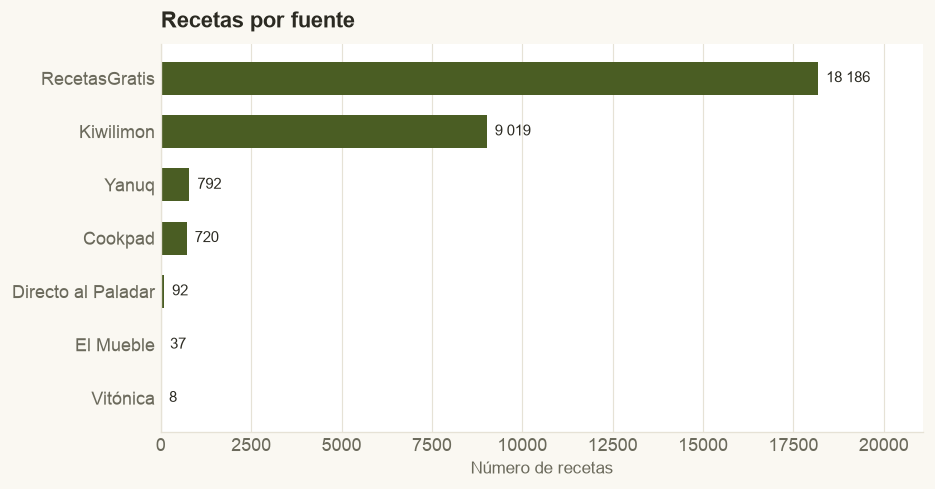

In [31]:
source_counts = eda["source"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8.2, 4.2))
fig.patch.set_facecolor(BG)
bars = ax.barh(source_counts.index, source_counts.values, color=OLIVE, height=0.62)
ax.xaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.set_title("Recetas por fuente")
finish_ax(ax, xlabel="Número de recetas")
for bar, val in zip(bars, source_counts.values):
    ax.text(val + max(source_counts.values) * 0.012, bar.get_y() + bar.get_height() / 2,
            f"{val:,}".replace(",", " "), va="center", ha="left", color=INK, fontsize=9)
ax.set_xlim(0, source_counts.max() * 1.16)
save_fig(fig, "01_recetas_por_fuente")
plt.show()


### 12.2 Cobertura de campos que la app necesita

La ficha de ChefWise no puede mostrarse bien si faltan categoría, minutos o dificultad.
El porcentaje de nulos aquí es una métrica de producto, no solo de calidad estadística.


Figura: 02_cobertura_campos_app.png


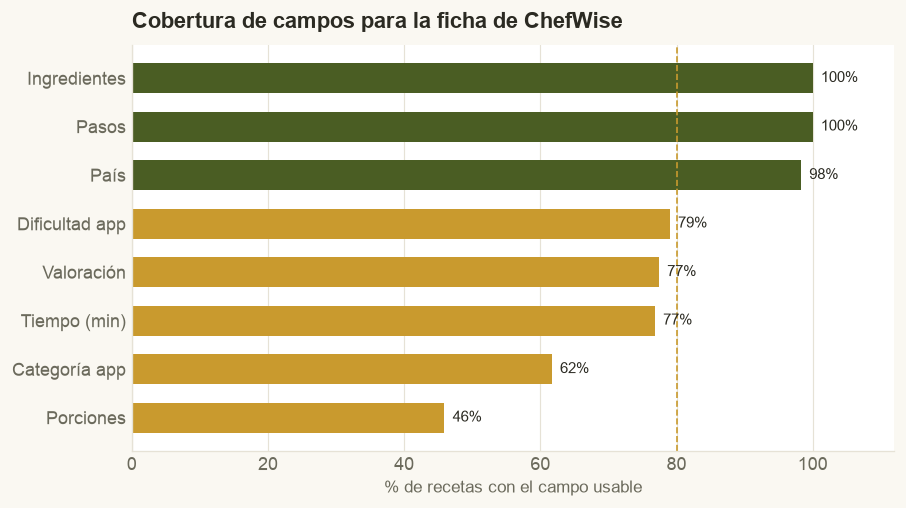

Interpretación: la línea al 80% marca un umbral razonable para filtros en producto.


,% cobertura
Porciones,45.9
Categoría app,61.7
Tiempo (min),76.8
Valoración,77.4
Dificultad app,79.0
País,98.3
Pasos,100.0
Ingredientes,100.0


In [32]:
app_fields = {
    "Ingredientes": eda["ingredients"].fillna("").ne(""),
    "Pasos": eda["instructions"].fillna("").ne(""),
    "Categoría app": eda["app_category"].notna(),
    "Dificultad app": eda["app_difficulty"].notna(),
    "Tiempo (min)": eda["total_time_min"].notna() & (eda["total_time_min"] > 0),
    "Porciones": eda["servings"].notna(),
    "País": eda["country"].notna(),
    "Valoración": eda["rating"].notna(),
}
coverage = pd.Series({k: 100 * v.mean() for k, v in app_fields.items()}).sort_values()

fig, ax = plt.subplots(figsize=(8.2, 4.4))
colors = [MUSTARD if val < 80 else OLIVE for val in coverage.values]
bars = ax.barh(coverage.index, coverage.values, color=colors, height=0.62)
ax.axvline(80, color=MUSTARD, linewidth=1, linestyle="--")
ax.xaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.set_title("Cobertura de campos para la ficha de ChefWise")
finish_ax(ax, xlabel="% de recetas con el campo usable")
ax.set_xlim(0, 112)
for bar, val in zip(bars, coverage.values):
    ax.text(val + 1.2, bar.get_y() + bar.get_height() / 2, f"{val:.0f}%",
            va="center", fontsize=9, color=INK)
save_fig(fig, "02_cobertura_campos_app")
plt.show()

print("Interpretación: la línea al 80% marca un umbral razonable para filtros en producto.")
display(coverage.round(1).to_frame("% cobertura"))


Figura: 03_completitud_por_fuente.png


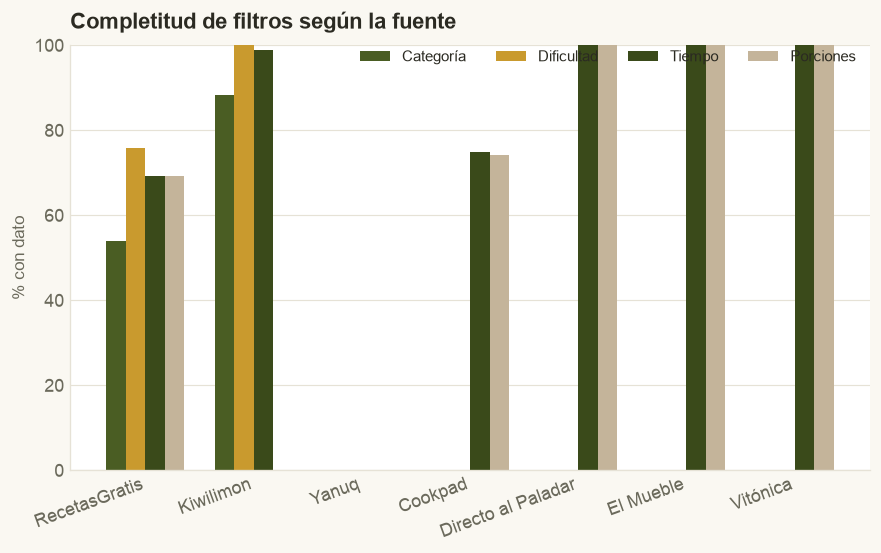

,Categoría,Dificultad,Tiempo,Porciones
source,,,,
RecetasGratis,54.1,75.8,69.2,69.2
Kiwilimon,88.3,100.0,98.8,0.0
Yanuq,0.0,0.0,0.0,0.0
Cookpad,0.0,0.0,74.9,74.2
Directo al Paladar,0.0,0.0,100.0,100.0
El Mueble,0.0,0.0,100.0,100.0
Vitónica,0.0,0.0,100.0,100.0


In [33]:
# Completitud por fuente (los huecos no están repartidos igual)
fields_by_source = (
    eda.assign(
        cat=eda["app_category"].notna(),
        diff=eda["app_difficulty"].notna(),
        time=(eda["total_time_min"].notna()) & (eda["total_time_min"] > 0),
        serv=eda["servings"].notna(),
    )
    .groupby("source")[["cat", "diff", "time", "serv"]]
    .mean()
    .mul(100)
    .reindex(eda["source"].value_counts().index)
)
fields_by_source.columns = ["Categoría", "Dificultad", "Tiempo", "Porciones"]

fig, ax = plt.subplots(figsize=(8.6, 4.6))
x = np.arange(len(fields_by_source))
width = 0.18
for i, (col, color) in enumerate(zip(fields_by_source.columns, [OLIVE, MUSTARD, OLIVE_DARK, SAND])):
    ax.bar(x + (i - 1.5) * width, fields_by_source[col], width=width, color=color, label=col)
ax.set_xticks(x)
ax.set_xticklabels(fields_by_source.index, rotation=20, ha="right")
ax.set_ylim(0, 100)
ax.yaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.legend(ncol=4, loc="upper right", bbox_to_anchor=(1, 1.02), fontsize=9)
ax.set_title("Completitud de filtros según la fuente")
finish_ax(ax, ylabel="% con dato")
save_fig(fig, "03_completitud_por_fuente")
plt.show()
display(fields_by_source.round(1))


### 12.3 Categoría de comida

La app solo tiene cinco casillas. Si muchas recetas quedan sin categoría, “Sorpréndeme”
y el resumen de Mi cocina se sesgan hacia `comida` y `postre`.


Figura: 04_categoria_app.png


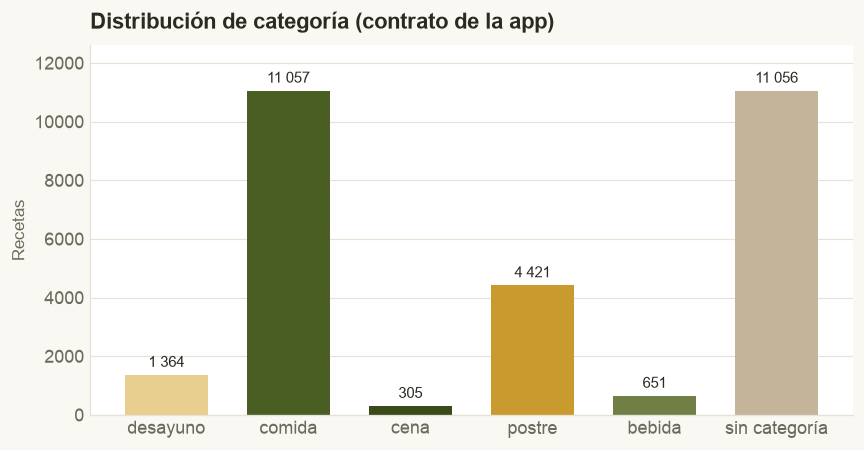

Sin categoría: 11056 (38.3%)


In [34]:
cat_order = ["desayuno", "comida", "cena", "postre", "bebida", "sin categoría"]
cat = eda["app_category"].fillna("sin categoría")
cat_counts = cat.value_counts().reindex(cat_order).fillna(0).astype(int)
cat_colors = {
    "desayuno": MUSTARD_SOFT,
    "comida": OLIVE,
    "cena": OLIVE_DARK,
    "postre": MUSTARD,
    "bebida": OLIVE_MID,
    "sin categoría": SAND,
}

fig, ax = plt.subplots(figsize=(8.2, 4.0))
bars = ax.bar(cat_counts.index, cat_counts.values,
              color=[cat_colors[c] for c in cat_counts.index], width=0.68)
ax.yaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.set_title("Distribución de categoría (contrato de la app)")
finish_ax(ax, ylabel="Recetas")
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + max(cat_counts.values) * 0.015,
            f"{val:,}".replace(",", " "), ha="center", va="bottom", fontsize=9, color=INK)
ax.set_ylim(0, cat_counts.max() * 1.14)
save_fig(fig, "04_categoria_app")
plt.show()
print("Sin categoría:", int(cat_counts["sin categoría"]),
      f"({100 * cat_counts['sin categoría'] / cat_counts.sum():.1f}%)")


### 12.4 Tiempo de preparación

En la tarjeta de ChefWise, `minutes` es un número que la persona usa para decidir
si cocina hoy. Valores de 0 minutos o de varios días (vinagre, o `30h` mal scrapeado)
rompen ese filtro.


Nulos: 6583
Igual a 0: 104
> 4 horas: 461
> 12 horas: 244
> 24 horas: 60
count    22271.0
mean        70.2
std        274.7
min          0.0
50%         40.0
90%         90.0
95%        150.0
99%       1200.0
max      30240.0
Name: total_time_min, dtype: float64
Figura: 05_tiempo_hasta_3h.png


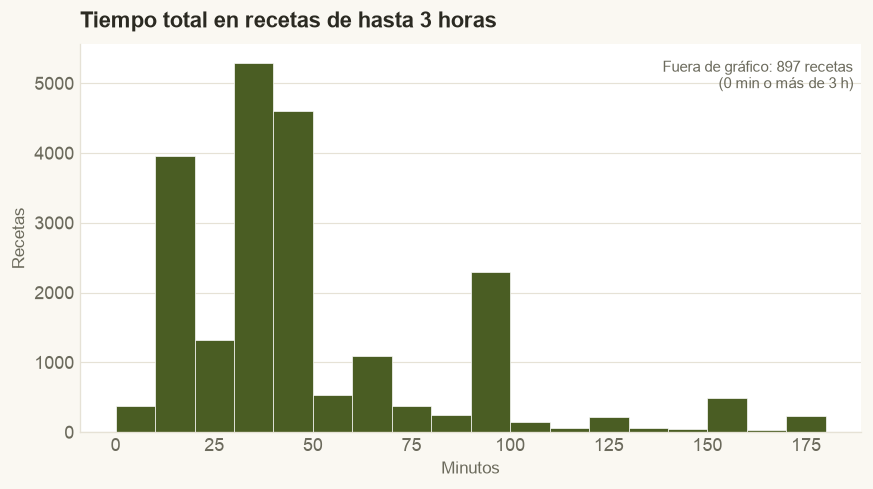


Ejemplos de tiempos extremos (> 24 h):


,name,source,prep_time_min,cook_time_min,total_time_min
23429,Vinagre de Piña,Kiwilimon,30240.0,0.0,30240.0
22521,Imposible de Cajeta con Manzana y Arándanos,Kiwilimon,5400.0,0.0,5400.0
27008,Ceviche a la Tampiqueña,Kiwilimon,5400.0,0.0,5400.0
23004,Pastel Sacher,Kiwilimon,4800.0,0.0,4800.0
25995,¿Cómo hacer tepache casero?,Kiwilimon,4335.0,0.0,4335.0
26054,Cupcakes de Chocolate Muy Fáciles,Kiwilimon,3660.0,0.0,3660.0
26685,Cupcakes de Zanahoria con Betún,Kiwilimon,3600.0,0.0,3600.0
21593,Cupcakes Oreo,Kiwilimon,3600.0,0.0,3600.0


In [35]:
times = eda["total_time_min"]
print("Nulos:", int(times.isna().sum()))
print("Igual a 0:", int((times == 0).sum()))
print("> 4 horas:", int((times > 240).sum()))
print("> 12 horas:", int((times > 720).sum()))
print("> 24 horas:", int((times > 1440).sum()))
print(times.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1))

# Histograma en el rango útil para una comida casera (hasta 3 h); los outliers se reportan aparte
plot_times = times[(times > 0) & (times <= 180)]

fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.hist(plot_times, bins=np.arange(0, 185, 10), color=OLIVE, edgecolor=SURFACE, linewidth=0.4)
ax.yaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.set_title("Tiempo total en recetas de hasta 3 horas")
finish_ax(ax, xlabel="Minutos", ylabel="Recetas")
n_out = int(((times > 180) | (times == 0)).sum())
ax.text(0.99, 0.96,
        f"Fuera de gráfico: {n_out:,} recetas\n(0 min o más de 3 h)".replace(",", " "),
        transform=ax.transAxes, ha="right", va="top", fontsize=9, color=INK_SOFT)
save_fig(fig, "05_tiempo_hasta_3h")
plt.show()

print("\nEjemplos de tiempos extremos (> 24 h):")
display(
    eda.loc[times > 1440, ["name", "source", "prep_time_min", "cook_time_min", "total_time_min"]]
    .sort_values("total_time_min", ascending=False)
    .head(8)
)


### 12.5 Dificultad, porciones e ingredientes

Sirven para filtrar “fácil / en 30 min / para 2” y para el motor de “con lo que tengo”.


Figura: 06_dificultad_e_ingredientes.png


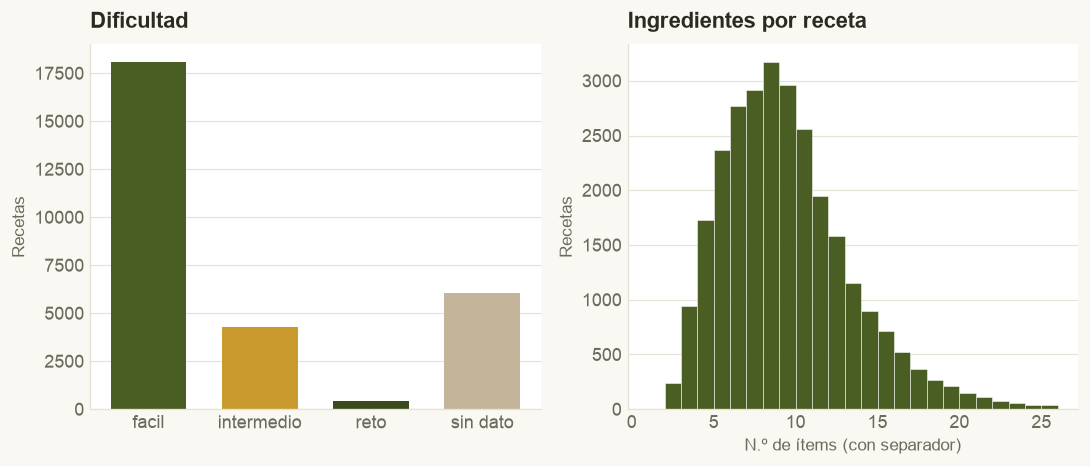

Porciones (cuando existen): mediana 4.0 | p95 10.0 | máx 100.0
Recetas sin conteo estructurado de ingredientes: 986


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.0))
fig.patch.set_facecolor(BG)

diff = eda["app_difficulty"].fillna("sin dato")
diff_order = ["facil", "intermedio", "reto", "sin dato"]
diff_counts = diff.value_counts().reindex(diff_order).fillna(0)
diff_colors = [OLIVE, MUSTARD, OLIVE_DARK, SAND]
axes[0].bar(diff_counts.index, diff_counts.values, color=diff_colors, width=0.68)
axes[0].yaxis.grid(True, color=LINE, linewidth=0.7)
axes[0].set_axisbelow(True)
axes[0].set_title("Dificultad")
finish_ax(axes[0], ylabel="Recetas")

ing = eda["n_ingredients_approx"].dropna()
ing_clip = ing[ing <= 25]
axes[1].hist(ing_clip, bins=np.arange(1, 27, 1), color=OLIVE, edgecolor=SURFACE, linewidth=0.3)
axes[1].yaxis.grid(True, color=LINE, linewidth=0.7)
axes[1].set_axisbelow(True)
axes[1].set_title("Ingredientes por receta")
finish_ax(axes[1], xlabel="N.º de ítems (con separador)", ylabel="Recetas")

plt.tight_layout()
save_fig(fig, "06_dificultad_e_ingredientes")
plt.show()

serv = eda["servings"].dropna()
print("Porciones (cuando existen): mediana", float(serv.median()), "| p95", float(serv.quantile(0.95)), "| máx", float(serv.max()))
print("Recetas sin conteo estructurado de ingredientes:", int(eda["n_ingredients_approx"].isna().sum()))


### 12.6 País y duplicados entre fuentes

El recomendador puede filtrar cocina mexicana vs española, pero Kiwilimon está etiquetado
México por origen del sitio. Los duplicados de nombre entre fuentes (p. ej. agua de horchata
en RecetasGratis y Kiwilimon) harían que el ranking muestre la misma idea dos veces.


Figura: 07_pais.png


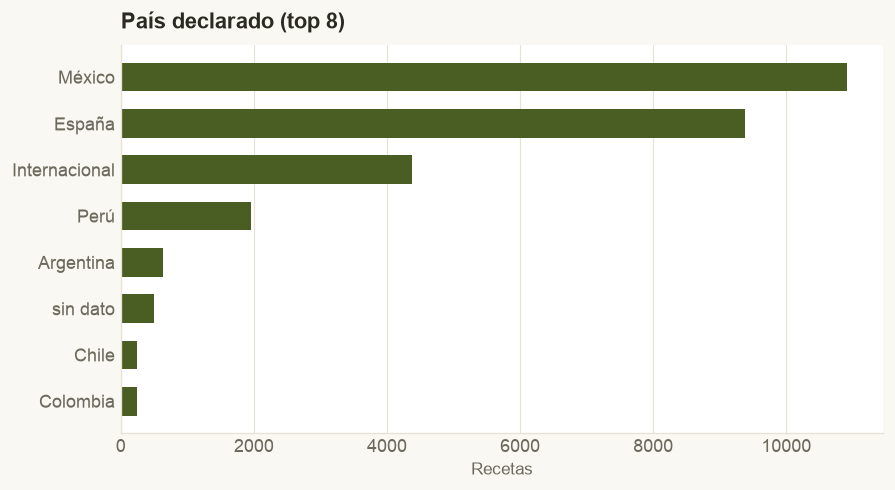

Filas que comparten nombre normalizado: 1422 en 660 nombres
URLs repetidas (Yanuq/El Mueble no traen URL única): 827


In [37]:
country = eda["country"].fillna("sin dato").value_counts().head(8).sort_values()

fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.barh(country.index, country.values, color=OLIVE, height=0.62)
ax.xaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.set_title("País declarado (top 8)")
finish_ax(ax, xlabel="Recetas")
save_fig(fig, "07_pais")
plt.show()

dup_name = eda.duplicated("name_key", keep=False)
print("Filas que comparten nombre normalizado:", int(dup_name.sum()),
      "en", eda.loc[dup_name, "name_key"].nunique(), "nombres")
print("URLs repetidas (Yanuq/El Mueble no traen URL única):", int(eda["url"].duplicated().sum()))


## 13. Lectura del EDA y ajustes de limpieza

Hallazgos que afectan al recomendador:

1. **~38% sin `app_category`.** Muchas sí son desayunos, postres o comidas; solo faltaba
   inferirlas de `meal_type`, tags y el nombre. `Acompañamiento` y `panes` no se habían mapeado.
2. **Tiempos imposibles para una ficha.** `0 min` aparece cuando Kiwilimon pone `0 mins` de
   cocción y no hay prep. Cientos de `30h` / `60h` en cupcakes o tacos son casi seguro minutos
   scrapeados como horas. Tiempos de fermentación reales (vinagre, 24 h) no deben usarse como
   “minutos para cocinar hoy”.
3. **Encoding.** El arreglo Latin-1 fallaba si el mismo texto traía emoji; quedaban `azÃºcar`.
4. **Mismo platillo en dos fuentes** (mismo nombre e ingredientes normalizados) duplicaría
   resultados. Nos quedamos con la fila más completa.
5. **Nombres en minúsculas** (RecetasGratis) frente a título (Kiwilimon): se unifica la
   capitalización para la UI.

No se borran recetas solo por ser postre, bebida o fermentación: el catálogo sigue siendo
amplio. Lo que se corrige es la **señal que ve el modelo y la ficha**.


In [38]:
recipes_before = recipes.copy()
n_before = len(recipes)

# --- 1) Categoría de la app más completa ---
MEAL_MAP_EXTRA = {
    "acompanamiento": "comida",
    "acompañamiento": "comida",
    "guarnicion": "comida",
    "guarnición": "comida",
    "cumpleanos": "postre",
    "cumpleaños": "postre",
    "panes": "desayuno",
    "salsas": "comida",
    "comida para ninos": "comida",
    "recetas navidenas": "comida",
    "recetas a la parrilla": "comida",
    "recetas faciles": "",
    "saludables": "",
}

NAME_RULES = [
    (r"\b(smoothie|licuado|agua de|atole|cafe|café|mojito|coctel|cóctel|spritz|horchata|tepache|kombucha|ponche|latte|margarita)\b", "bebida"),
    (r"\b(cupcake|muffin|brownie|galleta|galletas|pastel|pay|flan|helado|mousse|cheesecake|churro|churros|dona|donas|bizcocho|budin|budín)\b", "postre"),
    (r"\b(hotcake|pancake|waffle|omelette|omelet|huevos revueltos|chilaquiles|desayuno|avena|granola|tostada francesa)\b", "desayuno"),
    (r"\b(taco|enchilada|sopa|caldo|ensalada|pollo|arroz|pasta|pizza|empanada|quesadilla|guiso|lenteja|frijol|carne|pescado|camaron|camarón|lasagna|lasaña|hamburguesa|sandwich|sándwich|ceviche|pozole|mole|burrito|fajita|crema de)\b", "comida"),
]


def infer_app_category(row) -> str:
    current = row["app_category"] if pd.notna(row.get("app_category")) else ""
    if current:
        return current
    meal = map_app_category(row.get("meal_type") or "", row.get("category_tags") or "")
    if meal:
        return meal
    extra = MEAL_MAP_EXTRA.get(normalize_key(row.get("meal_type") or ""), "")
    if extra:
        return extra
    extra = MEAL_MAP_EXTRA.get(normalize_key(row.get("category_tags") or ""), "")
    if extra:
        return extra
    name = fix_text_encoding(row.get("name") or "").lower()
    for pattern, cat in NAME_RULES:
        if re.search(pattern, name, flags=re.I):
            return cat
    tags = normalize_key(row.get("category_tags") or "")
    if "postre" in tags:
        return "postre"
    if "desayuno" in tags:
        return "desayuno"
    if "bebida" in tags:
        return "bebida"
    return ""


# --- 2) Tiempo usable para la ficha ---
def clean_listed_time(row):
    listed = row["total_time_min"]
    prep = row["prep_time_min"]
    cook = row["cook_time_min"]
    source = row["source"]

    if pd.notna(cook) and cook == 0:
        cook = np.nan
    if pd.notna(prep) and prep == 0:
        prep = np.nan

    # Kiwilimon: "30h" / "60h" con cocción 0 casi siempre son minutos mal etiquetados.
    if source == "Kiwilimon" and pd.notna(prep) and prep >= 25 * 60:
        hours = prep / 60.0
        if hours > 96:
            prep = np.nan  # fermentación de días: no es tiempo de ficha
        else:
            prep = hours  # 30h → 30 min

    parts = [x for x in (prep, cook) if pd.notna(x)]
    if source == "Kiwilimon":
        total = float(np.nansum(parts)) if parts else np.nan
        if total == 0:
            total = np.nan
    else:
        total = listed
        if pd.notna(total) and total == 0:
            total = np.nan

    usable = total
    if pd.notna(usable) and usable > 12 * 60:
        usable = np.nan  # reposo/fermentación: no se ofrece como "minutos de hoy"
    return pd.Series({"prep_time_min": prep, "cook_time_min": cook,
                      "listed_time_min": listed, "total_time_min": usable})


# --- 3) Nombre para UI ---
_SMALL = {"de", "del", "la", "el", "los", "las", "y", "o", "u", "con", "en", "al",
          "a", "un", "una", "para", "por", "sin", "the", "and"}


def title_es(name: str) -> str:
    text = fix_text_encoding(name)
    text = re.sub(r"^¿?c[oó]mo hacer\s+", "", text, flags=re.I).strip(" ¿?")
    letters = [c for c in text if c.isalpha()]
    if letters and (sum(c.islower() for c in letters) / len(letters) > 0.8):
        words = re.split(r"(\s+|-)", text)
        out = []
        first_word = True
        for w in words:
            if not w or re.fullmatch(r"\s+|-", w):
                out.append(w)
                continue
            low = w.lower()
            if (not first_word) and low in _SMALL:
                out.append(low)
            else:
                out.append(low[:1].upper() + low[1:] if low else w)
            first_word = False
        text = "".join(out)
    return text


# --- 4) Encoding residual sobre columnas de texto ya unificadas ---
for col in ["name", "ingredients", "instructions", "context", "recipe_text"]:
    if col in recipes.columns:
        recipes[col] = recipes[col].map(lambda x: x if pd.isna(x) else fix_text_encoding(x))

recipes["name"] = recipes["name"].map(title_es)
recipes["name_key"] = recipes["name"].map(normalize_key)
recipes["app_category"] = recipes.apply(infer_app_category, axis=1).replace("", np.nan)

time_fix = recipes.apply(clean_listed_time, axis=1)
recipes["prep_time_min"] = time_fix["prep_time_min"]
recipes["cook_time_min"] = time_fix["cook_time_min"]
recipes["listed_time_min"] = time_fix["listed_time_min"]
recipes["total_time_min"] = time_fix["total_time_min"]

# --- 5) Duplicado entre fuentes: misma receta, nos quedamos con la ficha más completa ---
def completeness_score(row) -> float:
    score = 0.0
    for col in ["instructions", "app_category", "app_difficulty", "total_time_min",
                "servings", "rating", "diet_tags"]:
        val = row[col]
        if pd.notna(val) and str(val).strip() not in ("", "False"):
            score += 1
    n_ing = row["n_ingredients_approx"]
    score += 0.05 * (n_ing if pd.notna(n_ing) else 0)
    return score


recipes["_score"] = recipes.apply(completeness_score, axis=1)
recipes = (
    recipes.sort_values(["_score", "rating", "n_steps_approx"], ascending=False)
    .drop_duplicates(["name_key", "ingredients_key"], keep="first")
    .drop(columns="_score")
    .copy()
)

recipes["recipe_text"] = recipes.apply(combine_for_recommender, axis=1)
recipes["n_ingredients_approx"] = recipes["ingredients"].map(count_structured_items)
recipes["n_steps_approx"] = recipes["instructions"].map(count_structured_items)
recipes = recipes.reset_index(drop=True)
recipes["recipe_id"] = np.arange(1, len(recipes) + 1)

print("Recetas antes de ajustes EDA:", n_before)
print("Recetas después (dedup cruzado):", len(recipes))
print("Categoría: cobertura", f"{100 * recipes['app_category'].notna().mean():.1f}%",
      "(antes", f"{100 * recipes_before['app_category'].notna().mean():.1f}%)")
print("Tiempo usable: cobertura",
      f"{100 * (recipes['total_time_min'].notna() & (recipes['total_time_min'] > 0)).mean():.1f}%")
print("Tiempos > 12 h en ficha:", int((recipes["total_time_min"] > 720).sum()))
print("Tiempos = 0 en ficha:", int((recipes["total_time_min"] == 0).sum()))
print("Mojibake restante en instrucciones:",
      int(recipes["instructions"].astype(str).str.contains("Ã", na=False).sum()))


Recetas antes de ajustes EDA: 28854
Recetas después (dedup cruzado): 28854
Categoría: cobertura 76.4% (antes 61.7%)
Tiempo usable: cobertura 76.2%
Tiempos > 12 h en ficha: 0
Tiempos = 0 en ficha: 0
Mojibake restante en instrucciones: 3


### 13.1 Cómo queda el catálogo después de los ajustes

Las dos gráficas siguientes son las que más cambian la experiencia en app: categoría
(para navegar) y tiempo (para filtrar “qué cocino ahora”).


Figura: 08_categoria_antes_despues.png


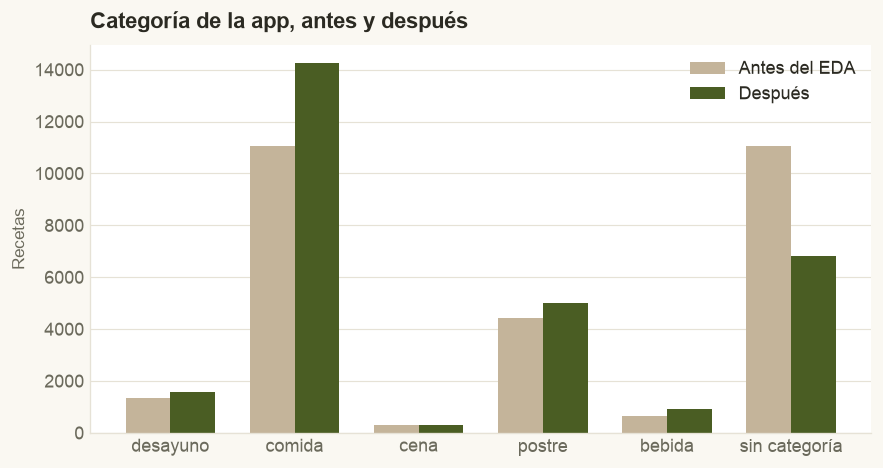

Figura: 09_tiempo_usable.png


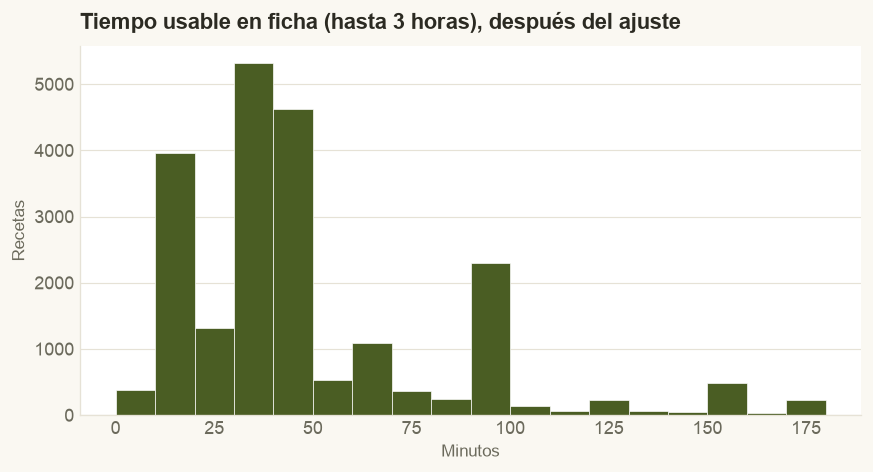

,Antes,Después
app_category,,
desayuno,1364,1582
comida,11057,14247
cena,305,305
postre,4421,4989
bebida,651,917
sin categoría,11056,6814


In [39]:
before_cat = recipes_before["app_category"].fillna("sin categoría").value_counts()
after_cat = recipes["app_category"].fillna("sin categoría").value_counts()
idx = ["desayuno", "comida", "cena", "postre", "bebida", "sin categoría"]
cmp = pd.DataFrame({"Antes": before_cat.reindex(idx).fillna(0),
                    "Después": after_cat.reindex(idx).fillna(0)})

fig, ax = plt.subplots(figsize=(8.4, 4.2))
x = np.arange(len(idx))
w = 0.36
ax.bar(x - w / 2, cmp["Antes"], width=w, color=SAND, label="Antes del EDA")
ax.bar(x + w / 2, cmp["Después"], width=w, color=OLIVE, label="Después")
ax.set_xticks(x)
ax.set_xticklabels(idx)
ax.yaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.legend(loc="upper right")
ax.set_title("Categoría de la app, antes y después")
finish_ax(ax, ylabel="Recetas")
save_fig(fig, "08_categoria_antes_despues")
plt.show()

times_after = recipes.loc[(recipes["total_time_min"] > 0) & (recipes["total_time_min"] <= 180), "total_time_min"]
fig, ax = plt.subplots(figsize=(8.4, 4.0))
ax.hist(times_after, bins=np.arange(0, 185, 10), color=OLIVE, edgecolor=SURFACE, linewidth=0.4)
ax.yaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.set_title("Tiempo usable en ficha (hasta 3 horas), después del ajuste")
finish_ax(ax, xlabel="Minutos", ylabel="Recetas")
save_fig(fig, "09_tiempo_usable")
plt.show()

display(cmp.astype(int))


## 14. Validación final y archivo processed

Se mantiene la regla de negocio: toda receta tiene nombre e ingredientes. El tiempo de
ficha nunca es 0 ni mayor a 12 horas. Las categorías, si existen, entran en el contrato
de la app.


In [40]:
assert recipes["recipe_id"].is_unique
assert recipes["name"].ne("").all()
assert recipes["ingredients"].ne("").all()
assert not recipes.duplicated(["name_key", "ingredients_key"]).any()
assert recipes["total_time_min"].dropna().gt(0).all()
assert recipes["total_time_min"].dropna().le(12 * 60).all()

valid_cat = {"desayuno", "comida", "cena", "postre", "bebida"}
valid_diff = {"facil", "intermedio", "reto"}
assert set(recipes["app_category"].dropna().unique()).issubset(valid_cat)
assert set(recipes["app_difficulty"].dropna().unique()).issubset(valid_diff)

print("Catálogo final:", recipes.shape)
print("\nPor fuente:")
display(recipes["source"].value_counts().to_frame("recetas"))
print("\nCategoría app:")
display(recipes["app_category"].value_counts(dropna=False).to_frame("recetas"))
print("\nNulos en campos de ficha:")
display(
    recipes[["app_category", "app_difficulty", "total_time_min", "servings", "instructions"]]
    .isna().sum().to_frame("nulos")
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
recipes.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print("\nGuardado:", OUTPUT_PATH)
print("Tamaño MB:", round(OUTPUT_PATH.stat().st_size / 1024 / 1024, 2))


Catálogo final: (28854, 30)

Por fuente:


,recetas
source,
RecetasGratis,18186
Kiwilimon,9019
Yanuq,792
Cookpad,720
Directo al Paladar,92
El Mueble,37
Vitónica,8



Categoría app:


,recetas
app_category,
comida,14247
NaN,6814
postre,4989
desayuno,1582
bebida,917
cena,305



Nulos en campos de ficha:


,nulos
app_category,6814
app_difficulty,6053
total_time_min,6879
servings,15605
instructions,4



Guardado: /Users/i./Documents/DIPLOMADO/MODULO_5/chefWise/data/processed/recetas_unificadas_limpias.csv
Tamaño MB: 65.33


## 15. Qué queda para el modelo y la app

- **Contenido:** `recipe_text` (nombre + ingredientes + tags). No incluye pasos a propósito.
- **Filtros de producto:** `app_category`, `app_difficulty`, `total_time_min` (tiempo usable),
  `servings`, `country`, `diet_tags`.
- **Mapeo a Angular:** `recipe_id` → `id`, `app_category` → `category`, `total_time_min` →
  `minutes`, `app_difficulty` → `difficulty`; partir ingredientes y pasos por ` | `.
- **Aún incompleto a propósito:** porciones en Kiwilimon, categoría en una parte de RecetasGratis
  sin pistas en el nombre, y `cena` (casi nadie etiqueta cena vs comida). Eso se puede completar
  después con un clasificador, no con reglas frágiles.
- **Interacciones:** favoritos, cocinado y “con lo que tengo” siguen siendo la señal que falta
  para un híbrido; el frontend ya deja el lugar para registrarlas.

Las figuras quedaron en `notebooks/figures/` para documentación.
